In [147]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
from torchvision.ops import box_iou, generalized_box_iou
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.optimize import linear_sum_assignment
from PIL import Image, ImageDraw
import random
import json
import time

# ==========================================
# ABLATION STUDY CONFIGURATIONS
# ==========================================
EXPERIMENTS = {
    'baseline': {
        'backbone_name': 'resnet18',
        'num_queries': 100,
        'use_augmentation': True,
        'description': 'Baseline: ResNet18 + 100 queries + augmentation'
    },
    'mobilenet': {
        'backbone_name': 'mobilenet_v2',
        'num_queries': 100,
        'use_augmentation': True,
        'description': 'MobileNetV2 + 100 queries + augmentation'
    },
    'query50': {
        'backbone_name': 'resnet18',
        'num_queries': 50,
        'use_augmentation': True,
        'description': 'ResNet18 + 50 queries + augmentation'
    },
    'no_aug': {
        'backbone_name': 'resnet18',
        'num_queries': 100,
        'use_augmentation': False,
        'description': 'ResNet18 + 100 queries + NO augmentation'
    }
}

BASE_CONFIG = {
    'lr': 2e-4,
    'lr_backbone': 2e-5,
    'batch_size': 8,
    'epochs': 30,
    'weight_decay': 1e-4,
    'clip_max_norm': 0.1,
    'hidden_dim': 128,
    'nheads': 4,
    'dropout': 0.0,
    'enc_layers': 2,
    'dec_layers': 2,
    'num_classes': 1,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'seed': 42
}

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [148]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [149]:

# ==========================================
# DATASET
# ==========================================

def read_split(filename):
    with open(filename, 'r') as f:
        return [line.strip() for line in f.readlines() if line.strip()]

import re

class PennFudanDataset(Dataset):
    def __init__(self, root, img_list, transforms=None):
        self.root = root
        self.transforms = transforms
        self.imgs = img_list

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_name = self.imgs[idx]
        if img_name.endswith('.png'):
            img_name = img_name[:-4]
        img_path = os.path.join(self.root, "Pedestrian", img_name + ".png")
        txt_path = os.path.join(self.root, "Pedestrian", img_name + ".txt")

        img = Image.open(img_path).convert("RGB")

        boxes = []
        with open(txt_path, "r") as f:
            content = f.read()
            matches = re.findall(r'\(\d+, \d+\) - \(\d+, \d+\)', content)

            for match in matches:
                coords = re.findall(r'\d+', match)
                xmin, ymin, xmax, ymax = map(float, coords)
                boxes.append([xmin, ymin, xmax, ymax])

        if len(boxes) > 0:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.zeros((len(boxes),), dtype=torch.int64)
        else:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx]),
            "orig_size": torch.as_tensor([img.size[1], img.size[0]]) # h, w
        }

        if self.transforms:
            img, target = self.transforms(img, target)

        return img, target

class DETRTransforms:
    def __init__(self, train=False, use_aug=True):
        self.train = train
        self.use_aug = use_aug
        self.normalize = T.Compose([
            T.ToTensor(),
            T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        self.color_jitter = T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05)

    def __call__(self, img, target):
        if self.train and self.use_aug:
            if random.random() > 0.5:
                img = self.color_jitter(img)
            if random.random() > 0.5:
                img = img.transpose(Image.FLIP_LEFT_RIGHT)
                if len(target["boxes"]) > 0:
                    boxes = target["boxes"]
                    boxes[:, [0, 2]] = img.size[0] - boxes[:, [2, 0]]
                    target["boxes"] = boxes

        w, h = img.size
        img = img.resize((512, 512), resample=Image.BILINEAR)
        if len(target["boxes"]) > 0:
            scale_w = 512 / w
            scale_h = 512 / h
            boxes = target["boxes"]
            boxes[:, [0, 2]] *= scale_w
            boxes[:, [1, 3]] *= scale_h
            boxes = boxes / 512.0
            boxes = torch.clamp(boxes, 0.0, 1.0)
            target["boxes"] = boxes

        img = self.normalize(img)
        return img, target

def collate_fn(batch):
    return tuple(zip(*batch))

In [150]:
# ==========================================
# MODEL
# ==========================================
class Backbone(nn.Module):
    def __init__(self, name, hidden_dim):
        super().__init__()
        if name == 'resnet18':
            weights = models.ResNet18_Weights.IMAGENET1K_V1
            backbone = models.resnet18(weights=weights)
            self.body = nn.Sequential(*list(backbone.children())[:-2])
            self.num_channels = 512
        elif name == 'mobilenet_v2':
            weights = models.MobileNet_V2_Weights.IMAGENET1K_V1
            backbone = models.mobilenet_v2(weights=weights)
            self.body = backbone.features
            self.num_channels = 1280
        else:
            raise ValueError(f"Unsupported backbone: {name}")

        self.conv = nn.Conv2d(self.num_channels, hidden_dim, 1)

    def forward(self, x):
        for module in self.body.modules():
            if isinstance(module, torch.nn.BatchNorm2d):
                module.eval()
        x = self.body(x)
        return self.conv(x)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=2500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div)
        pe[:, 1::2] = torch.cos(position * div)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:x.size(0), :].unsqueeze(1)

class TinyDETR(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.backbone = Backbone(config['backbone_name'], config['hidden_dim'])
        self.transformer = nn.Transformer(
            d_model=config['hidden_dim'],
            nhead=config['nheads'],
            num_encoder_layers=config['enc_layers'],
            num_decoder_layers=config['dec_layers'],
            dim_feedforward=config['hidden_dim']*4,
            dropout=config['dropout']
        )
        self.class_embed = nn.Linear(config['hidden_dim'], config['num_classes'] + 1)
        self.bbox_embed = nn.Sequential(
            nn.Linear(config['hidden_dim'], config['hidden_dim']),
            nn.ReLU(),
            nn.Linear(config['hidden_dim'], config['hidden_dim']),
            nn.ReLU(),
            nn.Linear(config['hidden_dim'], 4)
        )
        self.query_embed = nn.Parameter(torch.rand(config['num_queries'], config['hidden_dim']))
        self.pos_encoder = PositionalEncoding(config['hidden_dim'])

    def forward(self, x):
        features = self.backbone(x)
        b, c, h, w = features.shape
        src = features.flatten(2).permute(2, 0, 1)
        src = self.pos_encoder(src)
        tgt = self.query_embed.unsqueeze(1).repeat(1, b, 1)
        hs = self.transformer(src, tgt).transpose(0, 1)
        return {
            'pred_logits': self.class_embed(hs),
            'pred_boxes': self.bbox_embed(hs).sigmoid()
        }


In [151]:
# ==========================================
# LOSS AND MATCHER
# ==========================================
def box_cxcywh_to_xyxy(x):
    x_c, y_c, w, h = x.unbind(-1)
    return torch.stack([
        (x_c - 0.5*w), (y_c - 0.5*h),
        (x_c + 0.5*w), (y_c + 0.5*h)
    ], dim=-1)

class HungarianMatcher(nn.Module):
    def __init__(self, cost_class=1, cost_bbox=5, cost_giou=2):
        super().__init__()
        self.cost_class = cost_class
        self.cost_bbox = cost_bbox
        self.cost_giou = cost_giou

    @torch.no_grad()
    def forward(self, outputs, targets):
        bs, num_queries = outputs["pred_logits"].shape[:2]
        out_prob = outputs["pred_logits"].flatten(0, 1).softmax(-1)
        out_bbox = outputs["pred_boxes"].flatten(0, 1)

        tgt_ids = torch.cat([v["labels"] for v in targets]) if targets else torch.empty(0)
        tgt_bbox = torch.cat([v["boxes"] for v in targets]) if targets else torch.empty(0)

        if len(tgt_ids) == 0:
            return []

        cost_class = -out_prob[:, tgt_ids]
        cost_bbox = torch.cdist(out_bbox, tgt_bbox, p=1)
        cost_giou = -generalized_box_iou(
            box_cxcywh_to_xyxy(out_bbox),
            box_cxcywh_to_xyxy(tgt_bbox)
        )

        C = self.cost_bbox * cost_bbox + self.cost_class * cost_class + self.cost_giou * cost_giou
        C = C.view(bs, num_queries, -1).cpu()

        sizes = [len(v["boxes"]) for v in targets]
        indices = [linear_sum_assignment(c[i]) for i, c in enumerate(C.split(sizes, -1))]
        return [(torch.as_tensor(i, dtype=torch.int64), torch.as_tensor(j, dtype=torch.int64)) for i, j in indices]

class SetCriterion(nn.Module):
    def __init__(self, num_classes, matcher, weight_dict, eos_coef):
        super().__init__()
        self.num_classes = num_classes
        self.matcher = matcher
        self.weight_dict = weight_dict
        self.eos_coef = eos_coef

    def forward(self, outputs, targets):
        indices = self.matcher(outputs, targets)
        idx = self._get_src_permutation_idx(indices)
        src_logits = outputs['pred_logits']

        target_classes_o = torch.cat([t["labels"] for t in targets])
        target_classes = torch.full(
            src_logits.shape[:2],
            self.num_classes,
            dtype=torch.int64,
            device=src_logits.device
        )
        target_classes[idx] = target_classes_o

        weight = torch.ones(self.num_classes + 1, device=src_logits.device)
        weight[-1] = self.eos_coef
        loss_ce = F.cross_entropy(src_logits.transpose(1, 2), target_classes, weight=weight)

        src_boxes = outputs['pred_boxes'][idx]
        target_boxes = torch.cat([t['boxes'][i] for t, (_, i) in zip(targets, indices)], dim=0)

        num_boxes = sum(len(t["boxes"]) for t in targets)
        num_boxes = torch.as_tensor([num_boxes], dtype=torch.float, device=src_logits.device)
        num_boxes = torch.clamp(num_boxes / 1, min=1).item()

        loss_bbox = F.l1_loss(src_boxes, target_boxes, reduction='none').sum() / num_boxes
        loss_giou = (1 - torch.diag(generalized_box_iou(
            box_cxcywh_to_xyxy(src_boxes),
            box_cxcywh_to_xyxy(target_boxes)
        ))).sum() / num_boxes

        return {
            'loss_ce': loss_ce,
            'loss_bbox': loss_bbox,
            'loss_giou': loss_giou
        }

    def _get_src_permutation_idx(self, indices):
        batch_idx = torch.cat([torch.full_like(src, i) for i, (src, _) in enumerate(indices)])
        src_idx = torch.cat([src for (src, _) in indices])
        return batch_idx, src_idx


In [152]:
# ==========================================
# EVALUATION
# ==========================================
def calculate_map(pred_boxes, pred_scores, target_boxes, iou_thresh=0.5):
    tp_list, score_list, n_gts = [], [], 0
    for preds, scores, targets in zip(pred_boxes, pred_scores, target_boxes):
        n_gts += len(targets)
        if len(preds) == 0:
            continue
        sorted_ind = torch.argsort(scores, descending=True)
        preds, scores = preds[sorted_ind], scores[sorted_ind]
        if len(targets) == 0:
            tp_list.extend([0]*len(preds))
            score_list.extend(scores.tolist())
            continue

        target_used = [False]*len(targets)
        ious = box_iou(box_cxcywh_to_xyxy(preds), box_cxcywh_to_xyxy(targets))
        for i in range(len(preds)):
            best_iou, best_idx = 0, -1
            for j in range(len(targets)):
                if not target_used[j] and ious[i,j] > best_iou:
                    best_iou, best_idx = ious[i,j], j
            if best_iou >= iou_thresh:
                tp_list.append(1)
                target_used[best_idx] = True
            else:
                tp_list.append(0)
            score_list.append(scores[i].item())

    if n_gts == 0:
        return 0.0
    tp, scores = np.array(tp_list), np.array(score_list)
    indices = np.argsort(-scores)
    tp = tp[indices]
    precisions = np.cumsum(tp) / (np.cumsum(tp) + np.cumsum(1-tp) + 1e-6)
    recalls = np.cumsum(tp) / n_gts
    ap = 0
    for t in np.arange(0, 1.1, 0.1):
        if np.sum(recalls >= t) == 0:
            p = 0
        else:
            p = np.max(precisions[recalls >= t])
        ap += p / 11.0
    return ap

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    pb, ps, tb = [], [], []
    for imgs, tgts in loader:
        imgs = torch.stack(imgs).to(device)
        out = model(imgs)
        prob = out['pred_logits'].softmax(-1)[0, :, 0]
        keep = prob > 0.5

        pb.append(out['pred_boxes'][0, keep].cpu())
        ps.append(prob[keep].cpu())
        tb.append(tgts[0]['boxes'].cpu())
    return calculate_map(pb, ps, tb)


In [153]:
# ==========================================
# TRAINING FUNCTION
# ==========================================
def train_model(config, train_loader, val_loader, test_loader, exp_name):
    print(f"\n{'='*60}")
    print(f"Experiment: {exp_name}")
    print(f"Config: {config['description']}")
    print(f"{'='*60}\n")

    set_seed(config['seed'])

    model = TinyDETR(config).to(config['device'])
    criterion = SetCriterion(
        config['num_classes'],
        HungarianMatcher(),
        {'loss_ce': 1, 'loss_bbox': 5, 'loss_giou': 2},
        eos_coef=0.05
    ).to(config['device'])

    params = [
        {"params": [p for n, p in model.named_parameters() if "backbone" not in n and p.requires_grad]},
        {"params": [p for n, p in model.named_parameters() if "backbone" in n and p.requires_grad],
         "lr": config['lr_backbone']},
    ]
    optimizer = torch.optim.AdamW(params, lr=config['lr'], weight_decay=config['weight_decay'])
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)

    best_map = 0.0
    loss_history, map_history = [], []
    start_time = time.time()

    for epoch in range(config['epochs']):
        model.train()
        epoch_loss = 0
        for imgs, tgts in train_loader:
            imgs = torch.stack(imgs).to(config['device'])
            tgts = [{k: v.to(config['device']) for k, v in t.items()} for t in tgts]

            out = model(imgs)
            loss_dict = criterion(out, tgts)
            loss = sum(loss_dict[k] * criterion.weight_dict[k] for k in loss_dict.keys())

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), config['clip_max_norm'])
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        val_map = evaluate(model, val_loader, config['device'])
        scheduler.step()

        loss_history.append(avg_loss)
        map_history.append(val_map)

        if val_map > best_map:
            best_map = val_map
            torch.save(model.state_dict(), f'best_{exp_name}.pth')
            print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | Val mAP: {val_map:.4f} (*)")
        else:
            print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | Val mAP: {val_map:.4f}")

    training_time = time.time() - start_time

    # Load best model for test
    model.load_state_dict(torch.load(f'best_{exp_name}.pth'))
    test_map = evaluate(model, test_loader, config['device'])

    results = {
        'exp_name': exp_name,
        'config': config['description'],
        'backbone': config['backbone_name'],
        'num_queries': config['num_queries'],
        'augmentation': config['use_augmentation'],
        'best_val_map': best_map,
        'test_map': test_map,
        'training_time': training_time,
        'time_per_epoch': training_time / config['epochs'],
        'loss_history': loss_history,
        'map_history': map_history
    }

    print(f"\n{exp_name} COMPLETED:")
    print(f"  Best Val mAP: {best_map:.4f}")
    print(f"  Test mAP: {test_map:.4f}")
    print(f"  Training Time: {training_time/60:.1f} min ({training_time/config['epochs']:.1f}s/epoch)")

    return results, model


In [154]:
def plot_logs(results):
    """Plots and saves training curves."""
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    for res in results:
        plt.plot(res['loss_history'], label=res['exp_name'])
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    for res in results:
        plt.plot(res['map_history'], label=res['exp_name'])
    plt.title('Validation mAP')
    plt.xlabel('Epoch')
    plt.ylabel('mAP@0.5')
    plt.legend()

    plt.tight_layout()
    plt.savefig('training_curves.png')
    plt.show()

def visualize_predictions(model, loader, device, threshold=0.6, num_images=8):
    model.eval()
    images_shown = 0

    plt.figure(figsize=(24, 6))

    def clean_box_cxcywh_to_xyxy(x):
        x_c, y_c, w, h = x.unbind(-1)
        b = [(x_c - 0.5 * w), (y_c - 0.5 * h),
             (x_c + 0.5 * w), (y_c + 0.5 * h)]
        return torch.stack(b, dim=-1)

    with torch.no_grad():
        for imgs, tgts in loader:
            imgs_gpu = torch.stack(imgs).to(device)
            outputs = model(imgs_gpu)

            for i in range(len(imgs)):
                if images_shown >= num_images: break

                img_tensor = imgs[i].cpu()
                mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
                std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
                img_vis = img_tensor * std + mean
                img_vis = torch.clamp(img_vis, 0, 1).permute(1, 2, 0).numpy()
                h_img, w_img, _ = img_vis.shape

                probs = outputs['pred_logits'][i].softmax(-1)[:, 0]
                keep = probs > threshold

                boxes_cxcywh = outputs['pred_boxes'][i][keep].cpu()
                boxes_xyxy = clean_box_cxcywh_to_xyxy(boxes_cxcywh)

                gt_boxes_cxcywh = tgts[i]['boxes'].cpu()
                gt_boxes_xyxy = clean_box_cxcywh_to_xyxy(gt_boxes_cxcywh)

                plt.subplot(1, 8, images_shown + 1)
                plt.imshow(img_vis)

                for box in gt_boxes_xyxy:
                    x1, y1, x2, y2 = box.numpy()
                    x1, x2 = x1 * w_img, x2 * w_img
                    y1, y2 = y1 * h_img, y2 * h_img

                    rect = plt.Rectangle(
                        (x1, y1),
                        (x2 - x1),
                        (y2 - y1),
                        fill=False, color='green', linewidth=2
                    )
                    plt.gca().add_patch(rect)

                for box in boxes_xyxy:
                    x1, y1, x2, y2 = box.numpy()
                    x1, x2 = x1 * w_img, x2 * w_img
                    y1, y2 = y1 * h_img, y2 * h_img

                    rect = plt.Rectangle(
                        (x1, y1),
                        (x2 - x1),
                        (y2 - y1),
                        fill=False, color='red', linewidth=2
                    )
                    plt.gca().add_patch(rect)

                plt.axis('off')
                plt.title(f"Img {images_shown+1}")
                images_shown += 1

    plt.tight_layout()
    plt.savefig('final_qualitative_results.png')
    plt.show()
    print("New visualization completed: final_qualitative_results.png")

    plt.tight_layout()
    plt.savefig('qualitative_results_corrected.png')
    plt.show()
    print("Visualization completed: qualitative_results_corrected.png")

    plt.tight_layout()
    plt.savefig('final_qualitative_results.png')
    plt.show()
    plt.close()

Dataset loaded: 118 train, 25 val, 27 test

Experiment: baseline
Config: Baseline: ResNet18 + 100 queries + augmentation



/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 01 | Loss: 6.3405 | Val mAP: 0.3864 (*)
Epoch 02 | Loss: 4.4330 | Val mAP: 0.4236 (*)
Epoch 03 | Loss: 3.1073 | Val mAP: 0.6336 (*)
Epoch 04 | Loss: 2.3251 | Val mAP: 0.4676
Epoch 05 | Loss: 2.0347 | Val mAP: 0.4485
Epoch 06 | Loss: 1.8377 | Val mAP: 0.6025
Epoch 07 | Loss: 1.9470 | Val mAP: 0.5390
Epoch 08 | Loss: 1.8197 | Val mAP: 0.5782
Epoch 09 | Loss: 1.7943 | Val mAP: 0.6182
Epoch 10 | Loss: 1.7469 | Val mAP: 0.6501 (*)
Epoch 11 | Loss: 1.7567 | Val mAP: 0.7355 (*)
Epoch 12 | Loss: 1.7410 | Val mAP: 0.4226
Epoch 13 | Loss: 1.6771 | Val mAP: 0.7179
Epoch 14 | Loss: 1.6594 | Val mAP: 0.6508
Epoch 15 | Loss: 1.6546 | Val mAP: 0.6649
Epoch 16 | Loss: 1.6351 | Val mAP: 0.5343
Epoch 17 | Loss: 1.6949 | Val mAP: 0.5543
Epoch 18 | Loss: 1.6535 | Val mAP: 0.5550
Epoch 19 | Loss: 1.5986 | Val mAP: 0.7861 (*)
Epoch 20 | Loss: 1.6437 | Val mAP: 0.6685
Epoch 21 | Loss: 1.4782 | Val mAP: 0.6867
Epoch 22 | Loss: 1.4269 | Val mAP: 0.7532
Epoch 23 | Loss: 1.4497 | Val mAP: 0.6606
Epoch 24 |

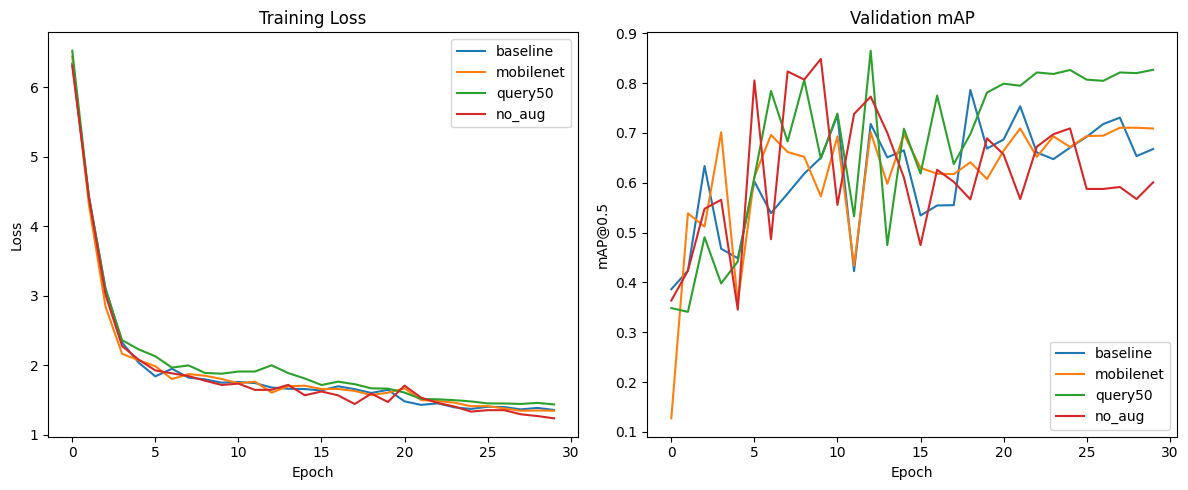

Generating visual results...


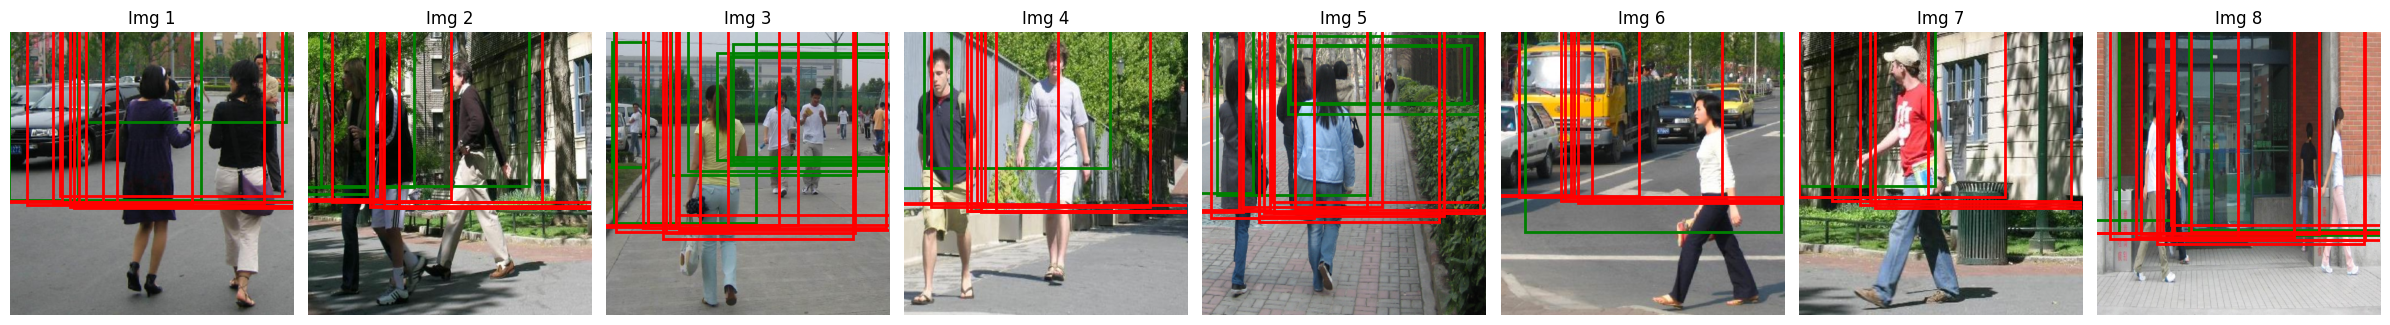

New visualization completed: final_qualitative_results.png


<Figure size 640x480 with 0 Axes>

Visualization completed: qualitative_results_corrected.png


<Figure size 640x480 with 0 Axes>


>>> SPECIAL TABLES FOR REPORT <<<

[Table 1] Backbone Comparison (ResNet18 vs MobileNetV2)
Backbone        Val mAP    Test mAP   Time/Epoch (s) 
-------------------------------------------------------
resnet18        0.7861     0.5195     8.0            
mobilenet_v2    0.7103     0.4024     5.9            

[Table 2] Query Count Ablation (Num Queries)
Queries    Backbone        Val mAP    Test mAP  
--------------------------------------------------
100        resnet18        0.7861     0.5195    
50         resnet18        0.8649     0.5182    

[Table 3] Impact of Data Augmentation
Augmentation    Val mAP    Test mAP  
----------------------------------------
Enabled         0.7861     0.5195    
Disabled        0.8483     0.5027    

[Final Result] Best Model (baseline): Test mAP@0.5 = 0.5195

[Visuals] Generating 8 test images (qualitative_results.png)...


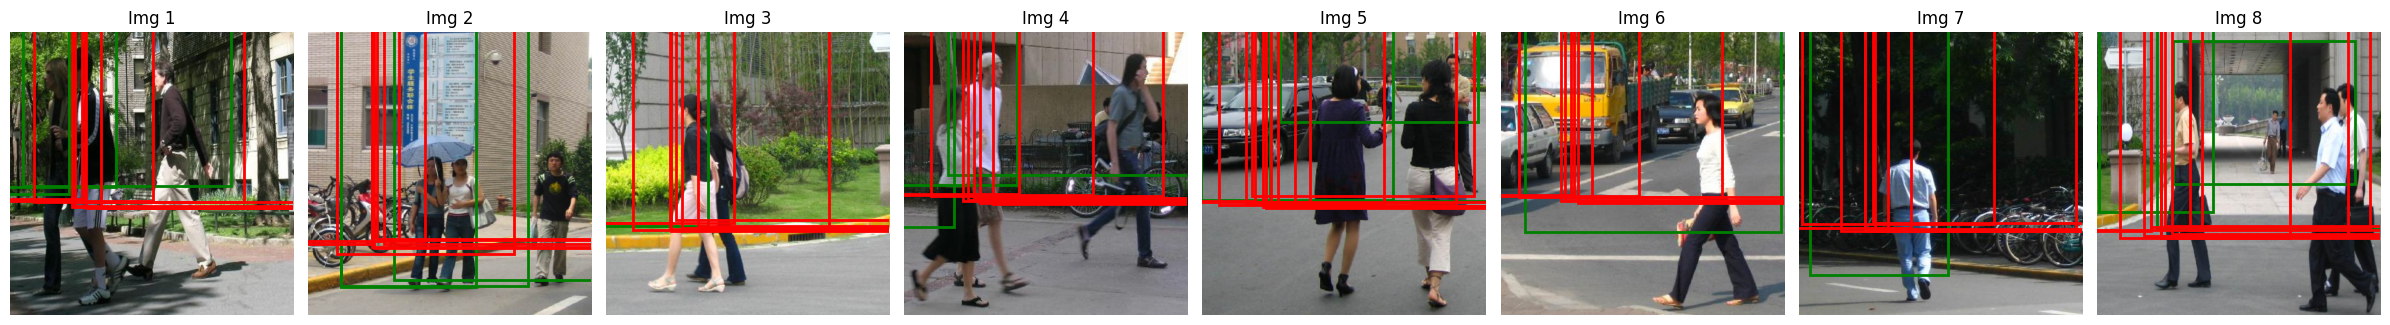

New visualization completed: final_qualitative_results.png


<Figure size 640x480 with 0 Axes>

Visualization completed: qualitative_results_corrected.png


<Figure size 640x480 with 0 Axes>

In [146]:
# ==========================================
# MAIN EXECUTION
# ==========================================
def main():
    TRAIN_FILES = read_split("/content/splits/train.txt")
    VAL_FILES = read_split("/content/splits/val.txt")
    TEST_FILES = read_split("/content/splits/test.txt")
    data_root = 'PennFudanPed'

    print(f"Dataset loaded: {len(TRAIN_FILES)} train, {len(VAL_FILES)} val, {len(TEST_FILES)} test")

    all_results = []

    # Run all experiments
    for exp_name, exp_config in EXPERIMENTS.items():
        config = {**BASE_CONFIG, **exp_config}

        # Create dataloaders with appropriate augmentation
        train_loader = DataLoader(
            PennFudanDataset('PennFudanPed', TRAIN_FILES,
                           transforms=DETRTransforms(True, config['use_augmentation'])),
            batch_size=config['batch_size'],
            shuffle=True,
            collate_fn=collate_fn
        )
        val_loader = DataLoader(
            PennFudanDataset('PennFudanPed', VAL_FILES,
                           transforms=DETRTransforms(False, False)),
            batch_size=config['batch_size'],
            shuffle=False,
            collate_fn=collate_fn
        )
        test_loader = DataLoader(
            PennFudanDataset('PennFudanPed', TEST_FILES,
                           transforms=DETRTransforms(False, False)),
            batch_size=1,
            shuffle=False,
            collate_fn=collate_fn
        )

        results, model = train_model(config, train_loader, val_loader, test_loader, exp_name)
        all_results.append(results)

        # Clean up GPU memory
        del model
        torch.cuda.empty_cache()

    with open('ablation_results.json', 'w') as f:
        json.dump(all_results, f, indent=2)

    # Print comparison table
    print("\n" + "="*80)
    print("ABLATION STUDY RESULTS")
    print("="*80)
    print(f"{'Experiment':<15} {'Backbone':<12} {'Queries':<8} {'Aug':<6} {'Val mAP':<10} {'Test mAP':<10} {'Time/Epoch':<12}")
    print("-"*80)
    for r in all_results:
        print(f"{r['exp_name']:<15} {r['backbone']:<12} {r['num_queries']:<8} "
              f"{'Yes' if r['augmentation'] else 'No':<6} "
              f"{r['best_val_map']:<10.4f} {r['test_map']:<10.4f} {r['time_per_epoch']:<12.1f}s")
    print("="*80)
    plot_logs(all_results)

    print("Generating visual results...")
    best_exp = max(all_results, key=lambda x: x['test_map'])
    best_model_path = f"best_{best_exp['exp_name']}.pth"

    model_config = {**BASE_CONFIG, **EXPERIMENTS[best_exp['exp_name']]}
    final_model = TinyDETR(model_config).to(BASE_CONFIG['device'])
    final_model.load_state_dict(torch.load(best_model_path))

    test_loader_vis = DataLoader(
            PennFudanDataset(data_root, TEST_FILES,
                           transforms=DETRTransforms(False, False)),
            batch_size=1, shuffle=True, collate_fn=collate_fn)

    visualize_predictions(final_model, test_loader_vis, BASE_CONFIG['device'])


    print("\n" + "="*40)
    print(">>> SPECIAL TABLES FOR REPORT <<<")
    print("="*40)

    print("\n[Table 1] Backbone Comparison (ResNet18 vs MobileNetV2)")
    print(f"{'Backbone':<15} {'Val mAP':<10} {'Test mAP':<10} {'Time/Epoch (s)':<15}")
    print("-" * 55)
    # Baseline (ResNet18) and MobileNet
    for r in all_results:
        if r['exp_name'] in ['baseline', 'mobilenet']:
            print(f"{r['backbone']:<15} {r['best_val_map']:<10.4f} {r['test_map']:<10.4f} {r['time_per_epoch']:<15.1f}")

    # 2. Query Count Table (50 vs 100)
    print("\n[Table 2] Query Count Ablation (Num Queries)")
    print(f"{'Queries':<10} {'Backbone':<15} {'Val mAP':<10} {'Test mAP':<10}")
    print("-" * 50)
    # Baseline (100) ve Query50
    for r in all_results:
        if r['exp_name'] in ['baseline', 'query50']:
            print(f"{r['num_queries']:<10} {r['backbone']:<15} {r['best_val_map']:<10.4f} {r['test_map']:<10.4f}")

    # 3. Augmentation Table (With vs Without)
    print("\n[Table 3] Impact of Data Augmentation")
    print(f"{'Augmentation':<15} {'Val mAP':<10} {'Test mAP':<10}")
    print("-" * 40)
    # Baseline (Aug Var) and No_Aug
    for r in all_results:
        if r['exp_name'] in ['baseline', 'no_aug']:
            status = "Enabled" if r['augmentation'] else "Disabled"
            print(f"{status:<15} {r['best_val_map']:<10.4f} {r['test_map']:<10.4f}")

    # 4. Final Result (Best Model)
    best_exp = max(all_results, key=lambda x: x['test_map'])
    print(f"\n[Final Result] Best Model ({best_exp['exp_name']}): Test mAP@0.5 = {best_exp['test_map']:.4f}")

    # 5. Qualitative Detections (6-8 Images)
    print("\n[Visuals] Generating 8 test images (qualitative_results.png)...")

    best_model_path = f"best_{best_exp['exp_name']}.pth"
    model_config = {**BASE_CONFIG, **EXPERIMENTS[best_exp['exp_name']]}
    final_model = TinyDETR(model_config).to(BASE_CONFIG['device'])
    final_model.load_state_dict(torch.load(best_model_path))

    # Test loader
    test_loader_vis = DataLoader(
        PennFudanDataset(data_root, TEST_FILES, transforms=DETRTransforms(False, False)),
        batch_size=1,
        shuffle=True,
        collate_fn=collate_fn
    )

    visualize_predictions(final_model, test_loader_vis, BASE_CONFIG['device'], threshold=0.6, num_images=8)

if __name__ == "__main__":
    main()